In [ ]:
# Bisection Method Solver
# Author: Owen Purnomo
# Date: 07/03/2026
# Assume that we are solving 𝑓(𝑥)=0. The desired level of error (in finding the zero of
# The function) is 𝜖, the initial guesses are 𝑥0 𝑎𝑛𝑑 𝑥1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
def make_function(expr_str):
    x = sp.symbols('x')
    expr = sp.sympify(expr_str)
    f = sp.lambdify(x, expr, modules=['numpy'])
    return f, expr

In [3]:
def secant(f, x0, x1, eps, max_iter=100):
    x_km1 = x0   # x_{k-1}
    x_k = x1     # x_k
    records = []
    k = 0

    while k <= max_iter:
        f_xk = f(x_k)
        f_xkm1 = f(x_km1)

        if f_xk - f_xkm1 == 0:
            raise ZeroDivisionError(
                f"f(x_k) - f(x_k-1) = 0 at x_k={x_k}, x_k-1={x_km1}, cannot continue"
            )

        x_k1 = x_k - ((x_k - x_km1) / (f_xk - f_xkm1)) * f_xk

        records.append({
            "k": k, "x_k-1": x_km1, "x_k": x_k,
            "f(x_k-1)": f_xkm1, "f(x_k)": f_xk,
            "x_k+1": x_k1, "|x_k+1 - x_k|": abs(x_k1 - x_k)
        })

        if abs(x_k1 - x_k) < eps:
            x_star = x_k1
            return x_star, pd.DataFrame(records)

        x_km1 = x_k
        x_k = x_k1
        k += 1

    raise RuntimeError("Max iterations reached without convergence")

In [4]:
def plot_secant(f, expr, history, x_star, padding=2, n_points=400):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x_vals_all = list(history["x_k"]) + list(history["x_k-1"]) + [x_star]
    x_min, x_max = min(x_vals_all) - padding, max(x_vals_all) + padding
    x_vals = np.linspace(x_min, x_max, n_points)
    y_vals = f(x_vals)

    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].plot(x_vals, y_vals, label=f"f(x) = {sp.pretty(expr, use_unicode=False)}", color="steelblue")
    axes[0].scatter(history["x_k"], [f(xk) for xk in history["x_k"]],
                     color="crimson", zorder=5, s=25, label="$x_k$ iterates")
    for _, row in history.iterrows():
        axes[0].annotate(str(int(row["k"])), (row["x_k"], f(row["x_k"])),
                          textcoords="offset points", xytext=(0, 8), fontsize=8, color="crimson")
    axes[0].scatter([x_star], [f(x_star)], color="green", zorder=6, s=60,
                     marker="*", label=f"root ≈ {x_star:.6f}")
    axes[0].set_title("Secant Method iterates on f(x)")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("f(x)")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["k"], history["|x_k+1 - x_k|"], marker="o", color="darkorange")
    axes[1].set_yscale("log")
    axes[1].set_title("Step size $|x_{k+1} - x_k|$ vs iteration")
    axes[1].set_xlabel("iteration k")
    axes[1].set_ylabel("$|x_{k+1} - x_k|$ (log scale)")
    axes[1].grid(alpha=0.3, which="both")

    plt.tight_layout()
    plt.show()

In [5]:
def solve_secant(expr_str, x0, x1, eps=1e-6, show_table=True, show_plot=True):
    f, expr = make_function(expr_str)
    x_star, history = secant(f, x0, x1, eps)

    print(f"f(x) = {expr}")
    print(f"Initial guesses: x0 = {x0}, x1 = {x1},  epsilon = {eps}")
    print(f"Approximate root: x* = {x_star:.8f}")
    print(f"f(x*) = {f(x_star):.2e}")
    print(f"Iterations used: {len(history)}")

    if show_table:
        display(history)

    if show_plot:
        plot_secant(f, expr, history, x_star)

    return x_star, history

f(x) = x**3 - x - 2
Initial guesses: x0 = 1, x1 = 2,  epsilon = 1e-06
Approximate root: x* = 1.52137971
f(x*) = -1.84e-14
Iterations used: 7


,k,x_k-1,x_k,f(x_k-1),f(x_k),x_k+1,|x_k+1 - x_k|
0,0,1.000000,2.000000,-2.000000,4.000000e+00,1.333333,6.666667e-01
1,1,2.000000,1.333333,4.000000,-9.629630e-01,1.462687,1.293532e-01
2,2,1.333333,1.462687,-0.962963,-3.333389e-01,1.531169,6.848286e-02
3,3,1.462687,1.531169,-0.333339,5.862642e-02,1.520926,1.024301e-02
4,4,1.531169,1.520926,0.058626,-2.693300e-03,1.521376,4.498962e-04
5,5,1.520926,1.521376,-0.002693,-2.015019e-05,1.521380,3.391315e-06
6,6,1.521376,1.521380,-0.000020,7.015478e-09,1.521380,1.180307e-09


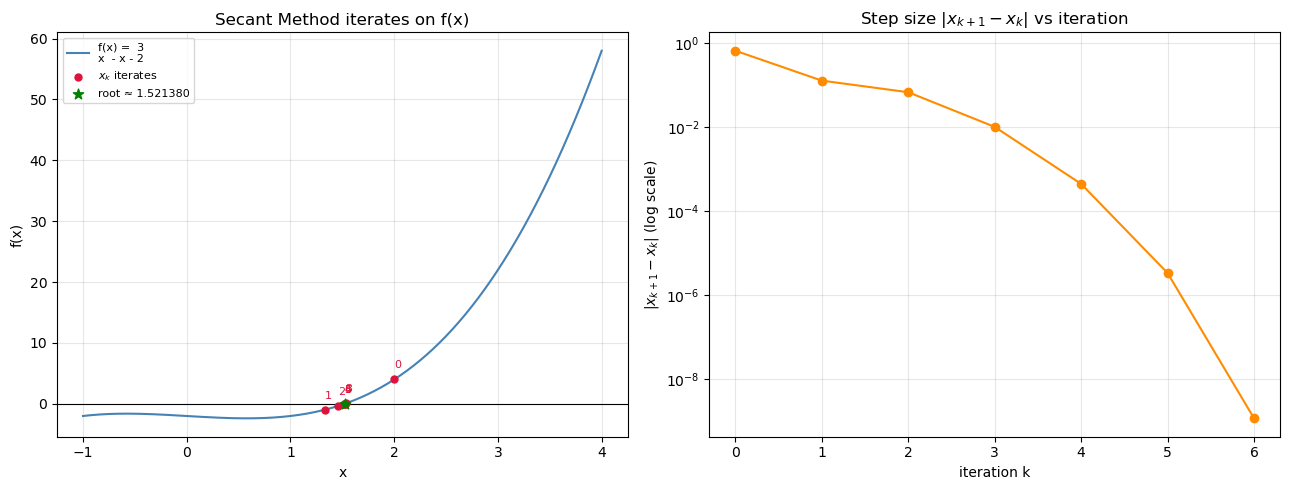

(1.5213797068045645,
    k     x_k-1       x_k  f(x_k-1)        f(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  1.000000  2.000000 -2.000000  4.000000e+00  1.333333   6.666667e-01
 1  1  2.000000  1.333333  4.000000 -9.629630e-01  1.462687   1.293532e-01
 2  2  1.333333  1.462687 -0.962963 -3.333389e-01  1.531169   6.848286e-02
 3  3  1.462687  1.531169 -0.333339  5.862642e-02  1.520926   1.024301e-02
 4  4  1.531169  1.520926  0.058626 -2.693300e-03  1.521376   4.498962e-04
 5  5  1.520926  1.521376 -0.002693 -2.015019e-05  1.521380   3.391315e-06
 6  6  1.521376  1.521380 -0.000020  7.015478e-09  1.521380   1.180307e-09)

In [6]:
solve_secant("x**3 - x - 2", x0=1, x1=2, eps=1e-6)

f(x) = x**2 - 2
Initial guesses: x0 = 1, x1 = 2,  epsilon = 1e-08
Approximate root: x* = 1.41421356
f(x*) = 8.88e-16
Iterations used: 6


,k,x_k-1,x_k,f(x_k-1),f(x_k),x_k+1,|x_k+1 - x_k|
0,0,1.000000,2.000000,-1.000000,2.000000e+00,1.333333,6.666667e-01
1,1,2.000000,1.333333,2.000000,-2.222222e-01,1.400000,6.666667e-02
2,2,1.333333,1.400000,-0.222222,-4.000000e-02,1.414634,1.463415e-02
3,3,1.400000,1.414634,-0.040000,1.189768e-03,1.414211,4.227079e-04
4,4,1.414634,1.414211,0.001190,-6.007287e-06,1.414214,2.123582e-06
5,5,1.414211,1.414214,-0.000006,-8.931456e-10,1.414214,3.157750e-10


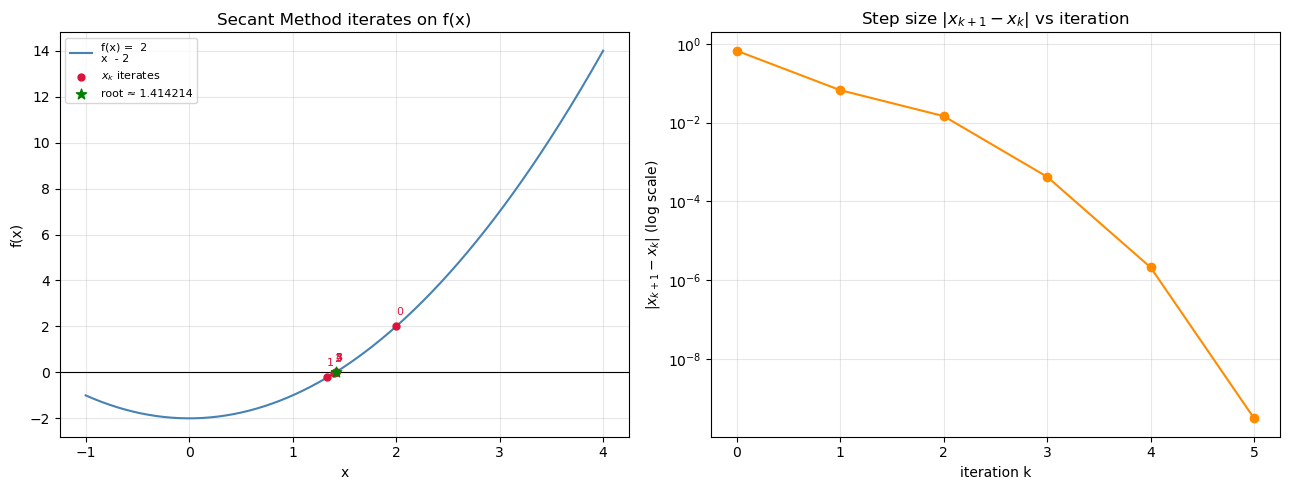

(1.4142135623730954,
    k     x_k-1       x_k  f(x_k-1)        f(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  1.000000  2.000000 -1.000000  2.000000e+00  1.333333   6.666667e-01
 1  1  2.000000  1.333333  2.000000 -2.222222e-01  1.400000   6.666667e-02
 2  2  1.333333  1.400000 -0.222222 -4.000000e-02  1.414634   1.463415e-02
 3  3  1.400000  1.414634 -0.040000  1.189768e-03  1.414211   4.227079e-04
 4  4  1.414634  1.414211  0.001190 -6.007287e-06  1.414214   2.123582e-06
 5  5  1.414211  1.414214 -0.000006 -8.931456e-10  1.414214   3.157750e-10)

In [7]:
solve_secant("x**2 - 2", x0=1, x1=2, eps=1e-8)

f(x) = -x + cos(x)
Initial guesses: x0 = 0, x1 = 1,  epsilon = 1e-08
Approximate root: x* = 0.73908513
f(x*) = 0.00e+00
Iterations used: 6


,k,x_k-1,x_k,f(x_k-1),f(x_k),x_k+1,|x_k+1 - x_k|
0,0,0.000000,1.000000,1.000000e+00,-4.596977e-01,0.685073,3.149266e-01
1,1,1.000000,0.685073,-4.596977e-01,8.929928e-02,0.736299,5.122564e-02
2,2,0.685073,0.736299,8.929928e-02,4.660039e-03,0.739119,2.820364e-03
3,3,0.736299,0.739119,4.660039e-03,-5.728599e-05,0.739085,3.424978e-05
4,4,0.739119,0.739085,-5.728599e-05,3.529262e-08,0.739085,2.108754e-08
5,5,0.739085,0.739085,3.529262e-08,2.667866e-13,0.739085,1.594280e-13


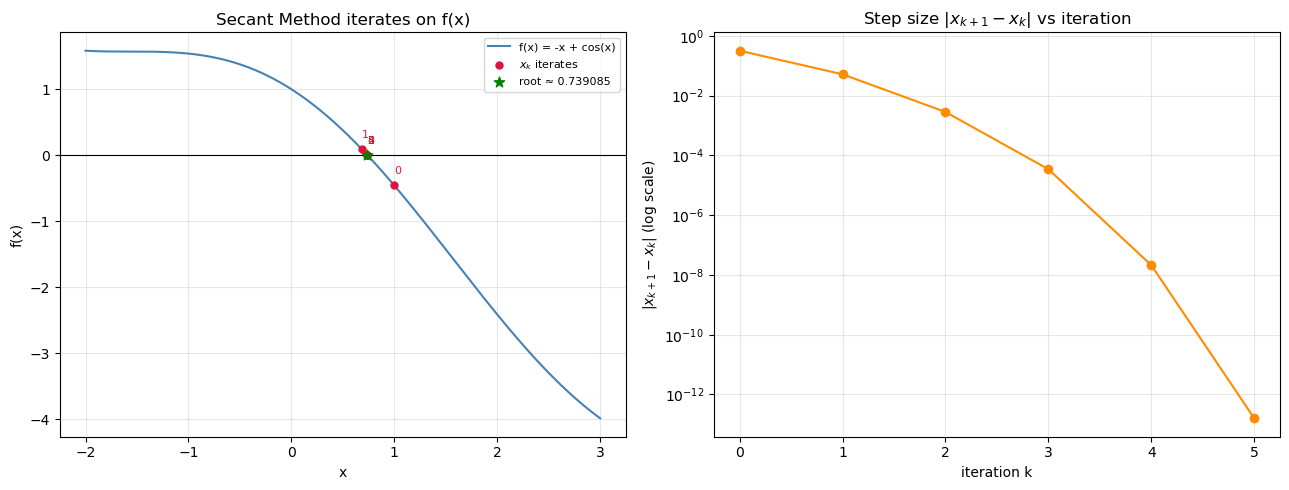

(0.7390851332151607,
    k     x_k-1       x_k      f(x_k-1)        f(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  0.000000  1.000000  1.000000e+00 -4.596977e-01  0.685073   3.149266e-01
 1  1  1.000000  0.685073 -4.596977e-01  8.929928e-02  0.736299   5.122564e-02
 2  2  0.685073  0.736299  8.929928e-02  4.660039e-03  0.739119   2.820364e-03
 3  3  0.736299  0.739119  4.660039e-03 -5.728599e-05  0.739085   3.424978e-05
 4  4  0.739119  0.739085 -5.728599e-05  3.529262e-08  0.739085   2.108754e-08
 5  5  0.739085  0.739085  3.529262e-08  2.667866e-13  0.739085   1.594280e-13)

In [8]:
solve_secant("cos(x) - x", x0=0, x1=1, eps=1e-8)

f(x) = -3*x + exp(x)
Initial guesses: x0 = 0, x1 = 1,  epsilon = 1e-06
Approximate root: x* = 0.61906129
f(x*) = -5.01e-13
Iterations used: 7


,k,x_k-1,x_k,f(x_k-1),f(x_k),x_k+1,|x_k+1 - x_k|
0,0,0.000000,1.000000,1.000000,-2.817182e-01,0.780203,2.197973e-01
1,1,1.000000,0.780203,-0.281718,-1.586936e-01,0.496679,2.835241e-01
2,2,0.780203,0.496679,-0.158694,1.532185e-01,0.635952,1.392736e-01
3,3,0.496679,0.635952,0.153218,-1.903683e-02,0.620560,1.539186e-02
4,4,0.635952,0.620560,-0.019037,-1.711113e-03,0.619040,1.520122e-03
5,5,0.620560,0.619040,-0.001711,2.401928e-05,0.619061,2.104291e-05
6,6,0.619040,0.619061,0.000024,-2.930685e-08,0.619061,2.564398e-08


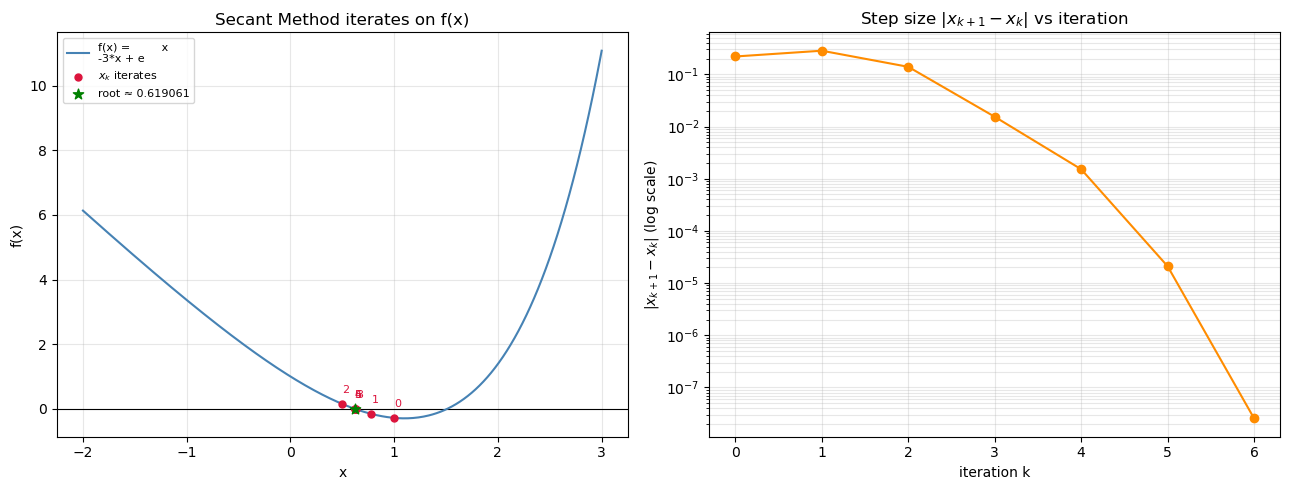

(0.6190612867363832,
    k     x_k-1       x_k  f(x_k-1)        f(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  0.000000  1.000000  1.000000 -2.817182e-01  0.780203   2.197973e-01
 1  1  1.000000  0.780203 -0.281718 -1.586936e-01  0.496679   2.835241e-01
 2  2  0.780203  0.496679 -0.158694  1.532185e-01  0.635952   1.392736e-01
 3  3  0.496679  0.635952  0.153218 -1.903683e-02  0.620560   1.539186e-02
 4  4  0.635952  0.620560 -0.019037 -1.711113e-03  0.619040   1.520122e-03
 5  5  0.620560  0.619040 -0.001711  2.401928e-05  0.619061   2.104291e-05
 6  6  0.619040  0.619061  0.000024 -2.930685e-08  0.619061   2.564398e-08)

In [9]:
solve_secant("exp(x) - 3*x", x0=0, x1=1, eps=1e-6)

f(x) = x**5 - x - 1
Initial guesses: x0 = 1, x1 = 1.5,  epsilon = 1e-08
Approximate root: x* = 1.16730398
f(x*) = 6.66e-16
Iterations used: 8


,k,x_k-1,x_k,f(x_k-1),f(x_k),x_k+1,|x_k+1 - x_k|
0,0,1.000000,1.500000,-1.000000e+00,5.093750e+00,1.082051,4.179487e-01
1,1,1.500000,1.082051,5.093750e+00,-5.987164e-01,1.126010,4.395858e-02
2,2,1.082051,1.126010,-5.987164e-01,-3.158748e-01,1.175102,4.909254e-02
3,3,1.126010,1.175102,-3.158748e-01,6.557107e-02,1.166663,8.439075e-03
4,4,1.175102,1.166663,6.557107e-02,-5.300214e-03,1.167294,6.311287e-04
5,5,1.166663,1.167294,-5.300214e-03,-7.886184e-05,1.167304,9.532391e-06
6,6,1.167294,1.167304,-7.886184e-05,9.708233e-08,1.167304,1.172036e-08
7,7,1.167304,1.167304,9.708233e-08,-1.774580e-12,1.167304,2.142730e-13


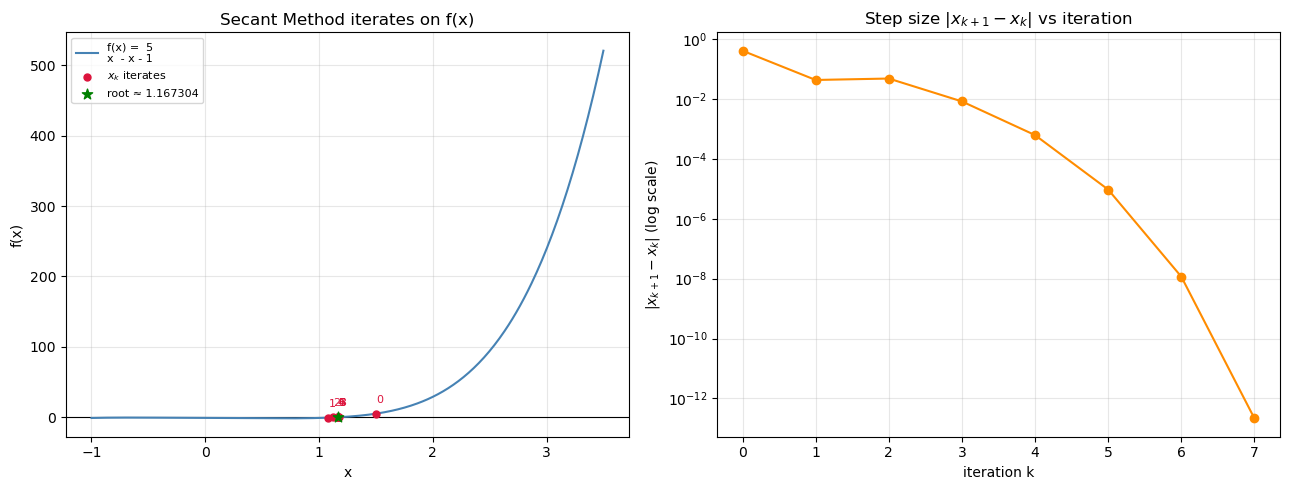

(1.1673039782614187,
    k     x_k-1       x_k      f(x_k-1)        f(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  1.000000  1.500000 -1.000000e+00  5.093750e+00  1.082051   4.179487e-01
 1  1  1.500000  1.082051  5.093750e+00 -5.987164e-01  1.126010   4.395858e-02
 2  2  1.082051  1.126010 -5.987164e-01 -3.158748e-01  1.175102   4.909254e-02
 3  3  1.126010  1.175102 -3.158748e-01  6.557107e-02  1.166663   8.439075e-03
 4  4  1.175102  1.166663  6.557107e-02 -5.300214e-03  1.167294   6.311287e-04
 5  5  1.166663  1.167294 -5.300214e-03 -7.886184e-05  1.167304   9.532391e-06
 6  6  1.167294  1.167304 -7.886184e-05  9.708233e-08  1.167304   1.172036e-08
 7  7  1.167304  1.167304  9.708233e-08 -1.774580e-12  1.167304   2.142730e-13)

In [10]:
solve_secant("x**5 - x - 1", x0=1, x1=1.5, eps=1e-8)

f(x) = x**3 - 7*x + 6
Initial guesses: x0 = 0.5, x1 = 1.5,  epsilon = 1e-06
Approximate root: x* = 1.00000000
f(x*) = -2.60e-10
Iterations used: 7


,k,x_k-1,x_k,f(x_k-1),f(x_k),x_k+1,|x_k+1 - x_k|
0,0,0.500000,1.500000,2.625000,-1.125000,1.200000,3.000000e-01
1,1,1.500000,1.200000,-1.125000,-0.672000,0.754967,4.450331e-01
2,2,1.200000,0.754967,-0.672000,1.145544,1.035458,2.804912e-01
3,3,0.754967,1.035458,1.145544,-0.138016,1.005298,3.016003e-02
4,4,1.035458,1.005298,-0.138016,-0.021108,0.999853,5.445378e-03
5,5,1.005298,0.999853,-0.021108,0.000590,1.000001,1.479546e-04
6,6,0.999853,1.000001,0.000590,-0.000002,1.000000,5.887781e-07


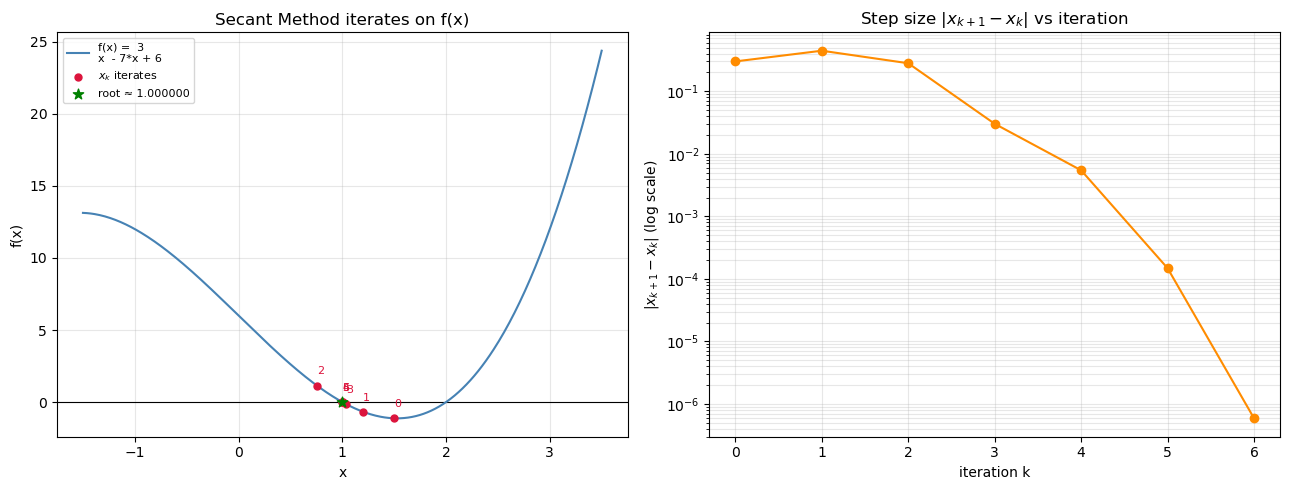

f(x) = x**3 - 7*x + 6
Initial guesses: x0 = -4, x1 = -2,  epsilon = 1e-06
Approximate root: x* = -3.00000000
f(x*) = 0.00e+00
Iterations used: 8


,k,x_k-1,x_k,f(x_k-1),f(x_k),x_k+1,|x_k+1 - x_k|
0,0,-4.000000,-2.000000,-30.000000,1.200000e+01,-2.571429,5.714286e-01
1,1,-2.000000,-2.571429,12.000000,6.997085e+00,-3.370629,7.992008e-01
2,2,-2.571429,-3.370629,6.997085,-8.699795e+00,-2.927683,4.429468e-01
3,3,-3.370629,-2.927683,-8.699795,1.399659e+00,-2.989069,6.138693e-02
4,4,-2.927683,-2.989069,1.399659,2.175364e-01,-3.000366,1.129654e-02
5,5,-2.989069,-3.000366,0.217536,-7.321593e-03,-2.999998,3.678262e-04
6,6,-3.000366,-2.999998,-0.007322,3.613632e-05,-3.000000,1.806520e-06
7,7,-2.999998,-3.000000,0.000036,5.951229e-09,-3.000000,2.975615e-10


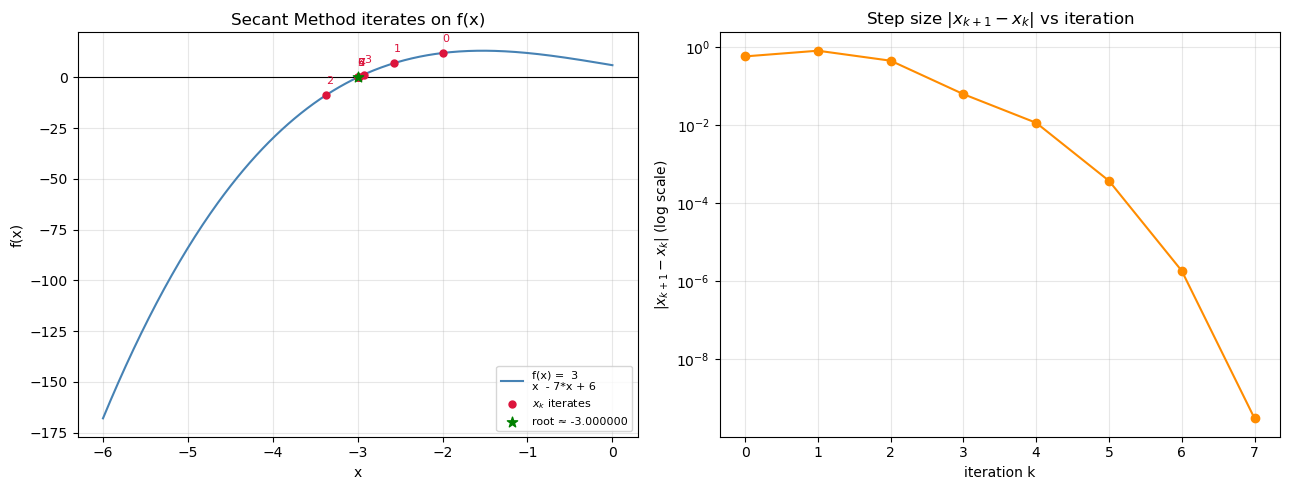

f(x) = x**3 - 7*x + 6
Initial guesses: x0 = 1.5, x1 = 3,  epsilon = 1e-06
Approximate root: x* = 2.00000000
f(x*) = 6.73e-10
Iterations used: 9


,k,x_k-1,x_k,f(x_k-1),f(x_k),x_k+1,|x_k+1 - x_k|
0,0,1.500000,3.000000,-1.125000,12.000000,1.628571,1.371429e+00
1,1,3.000000,1.628571,12.000000,-1.080630,1.741869,1.132978e-01
2,2,1.628571,1.741869,-1.080630,-0.908065,2.338060,5.961904e-01
3,3,1.741869,2.338060,-0.908065,2.414639,1.904803,4.332570e-01
4,4,2.338060,1.904803,2.414639,-0.422474,1.969319,6.451627e-02
5,5,1.904803,1.969319,-0.422474,-0.147786,2.004030,3.471076e-02
6,6,1.969319,2.004030,-0.147786,0.020246,1.999847,4.182216e-03
7,7,2.004030,1.999847,0.020246,-0.000763,1.999999,1.518211e-04
8,8,1.999847,1.999999,-0.000763,-0.000004,2.000000,7.348882e-07


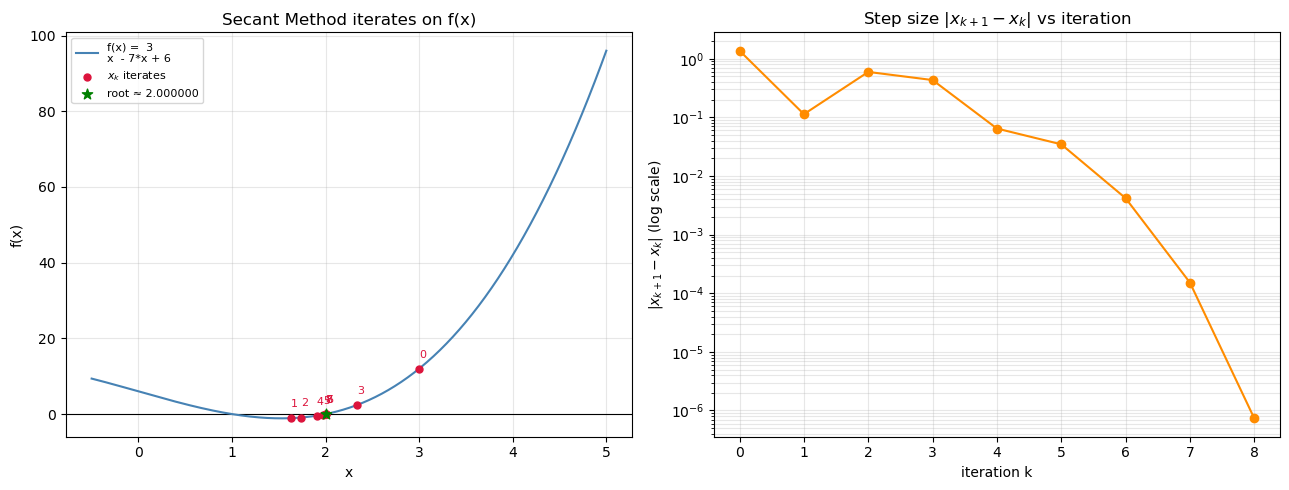

(2.0000000001345306,
    k     x_k-1       x_k   f(x_k-1)     f(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  1.500000  3.000000  -1.125000  12.000000  1.628571   1.371429e+00
 1  1  3.000000  1.628571  12.000000  -1.080630  1.741869   1.132978e-01
 2  2  1.628571  1.741869  -1.080630  -0.908065  2.338060   5.961904e-01
 3  3  1.741869  2.338060  -0.908065   2.414639  1.904803   4.332570e-01
 4  4  2.338060  1.904803   2.414639  -0.422474  1.969319   6.451627e-02
 5  5  1.904803  1.969319  -0.422474  -0.147786  2.004030   3.471076e-02
 6  6  1.969319  2.004030  -0.147786   0.020246  1.999847   4.182216e-03
 7  7  2.004030  1.999847   0.020246  -0.000763  1.999999   1.518211e-04
 8  8  1.999847  1.999999  -0.000763  -0.000004  2.000000   7.348882e-07)

In [11]:
solve_secant("x**3 - 7*x + 6", x0=0.5, x1=1.5, eps=1e-6)
solve_secant("x**3 - 7*x + 6", x0=-4, x1=-2, eps=1e-6)
solve_secant("x**3 - 7*x + 6", x0=1.5, x1=3, eps=1e-6)